# Employee Productivity Predictor — Model Training

## Business problem

HR wants a quick way to estimate an employee's **Monthly Productivity Score
(0-100)** from information they already track — department, job level,
experience, training, working hours, workload, absences, and engagement
survey results. A reliable estimate lets managers:

- Flag employees whose predicted productivity is trending low so they can
  intervene early (extra training, workload rebalancing, engagement
  check-ins).
- Understand *which* factors move productivity the most (via the model's
  learned coefficients), to prioritize HR programs with the best expected
  return.

This notebook loads `data.csv`, explores it, checks the assumptions behind
linear regression (the model we're using, chosen for its interpretability),
applies fixes where needed, trains a scikit-learn **Pipeline** (preprocessing
+ model), evaluates it on held-out data, and saves the final pipeline to
`model.pkl` for the Streamlit app (`app.py`) to load.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 1
pd.set_option("display.width", 120)


## 1. Load the dataset

In [2]:
df = pd.read_csv("data.csv")
print(df.shape)
df.head()


(5000, 11)


,Employee_ID,Department,Job_Level,Years_of_Experience,Training_Hours,Monthly_Working_Hours,Projects_Completed,Average_Task_Completion_Time,Absence_Days,Engagement_Score,Monthly_Productivity_Score
0,EMP00001,Operations,Junior,0.0,58.3,191.8,2,12.19,6,38.7,32.85
1,EMP00002,HR,Senior,9.8,43.1,179.9,6,6.85,4,56.0,67.29
2,EMP00003,Operations,Senior,5.0,35.2,173.7,6,10.83,5,67.5,67.08
3,EMP00004,Finance,Junior,2.9,42.6,199.3,4,9.33,1,57.5,52.98
4,EMP00005,Sales,Junior,2.9,35.0,175.2,6,7.21,2,69.0,57.33


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Employee_ID                   5000 non-null   str    
 1   Department                    5000 non-null   str    
 2   Job_Level                     5000 non-null   str    
 3   Years_of_Experience           5000 non-null   float64
 4   Training_Hours                5000 non-null   float64
 5   Monthly_Working_Hours         5000 non-null   float64
 6   Projects_Completed            5000 non-null   int64  
 7   Average_Task_Completion_Time  5000 non-null   float64
 8   Absence_Days                  5000 non-null   int64  
 9   Engagement_Score              5000 non-null   float64
 10  Monthly_Productivity_Score    5000 non-null   float64
dtypes: float64(6), int64(2), str(3)
memory usage: 429.8 KB


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee_ID,5000,5000,EMP00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,5000,7,Engineering,1105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Level,5000,5,Junior,1502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Years_of_Experience,5000.0,NaN,NaN,NaN,6.83678,5.995637,0.0,2.1,5.0,10.0,31.1
Training_Hours,5000.0,NaN,NaN,NaN,46.09708,15.712186,4.0,35.5,46.0,57.0,98.4
Monthly_Working_Hours,5000.0,NaN,NaN,NaN,175.41386,13.871299,130.0,166.1,175.4,184.5,215.0
Projects_Completed,5000.0,NaN,NaN,NaN,4.9918,2.8446,0.0,3.0,5.0,7.0,20.0
Average_Task_Completion_Time,5000.0,NaN,NaN,NaN,8.711016,1.875873,2.07,7.48,8.8,10.01,15.16
Absence_Days,5000.0,NaN,NaN,NaN,3.116,1.819122,0.0,2.0,3.0,4.0,12.0
Engagement_Score,5000.0,NaN,NaN,NaN,64.0457,12.72358,20.4,55.2,64.2,72.6,100.0


In [5]:
# Missing values check
missing = df.isna().sum()
print(missing[missing > 0] if missing.sum() else "No missing values.")


No missing values.


In [6]:
# Duplicate rows check
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate Employee_ID values: {df['Employee_ID'].duplicated().sum()}")


Duplicate rows: 0
Duplicate Employee_ID values: 0


## 2. Exploratory Data Analysis

In [7]:
TARGET = "Monthly_Productivity_Score"
NUMERIC_FEATURES = ['Years_of_Experience', 'Training_Hours', 'Monthly_Working_Hours', 'Projects_Completed', 'Average_Task_Completion_Time', 'Absence_Days', 'Engagement_Score']
CATEGORICAL_FEATURES = ['Department', 'Job_Level']


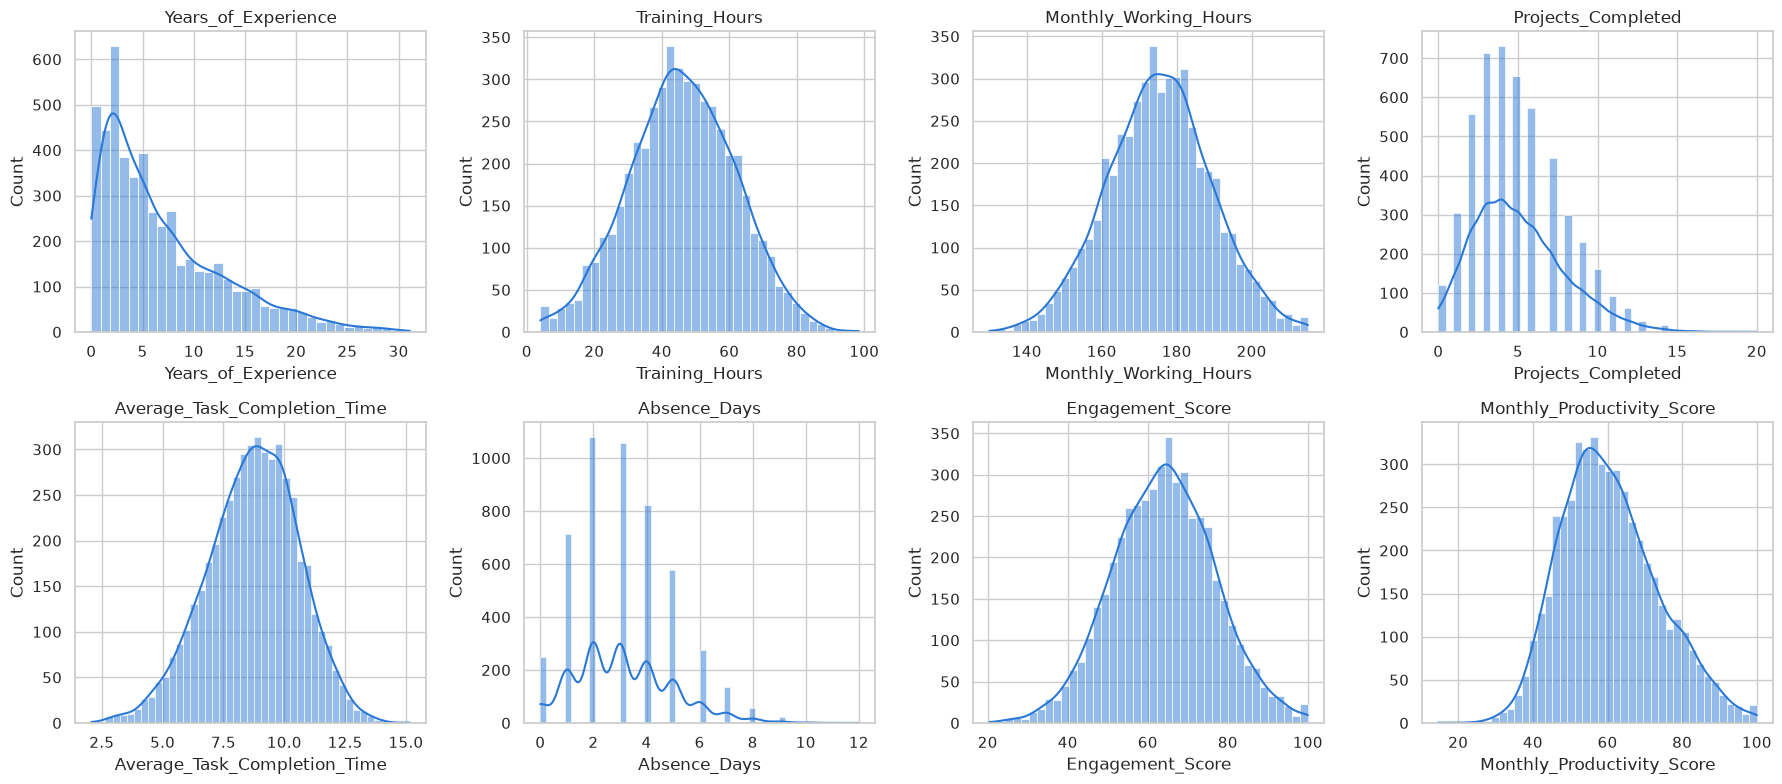

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, NUMERIC_FEATURES + [TARGET]):
    sns.histplot(df[col], kde=True, ax=ax, color="#2a78d6")
    ax.set_title(col)
axes.flat[-1].axis("off") if len(NUMERIC_FEATURES) + 1 < axes.size else None
plt.tight_layout()
plt.show()


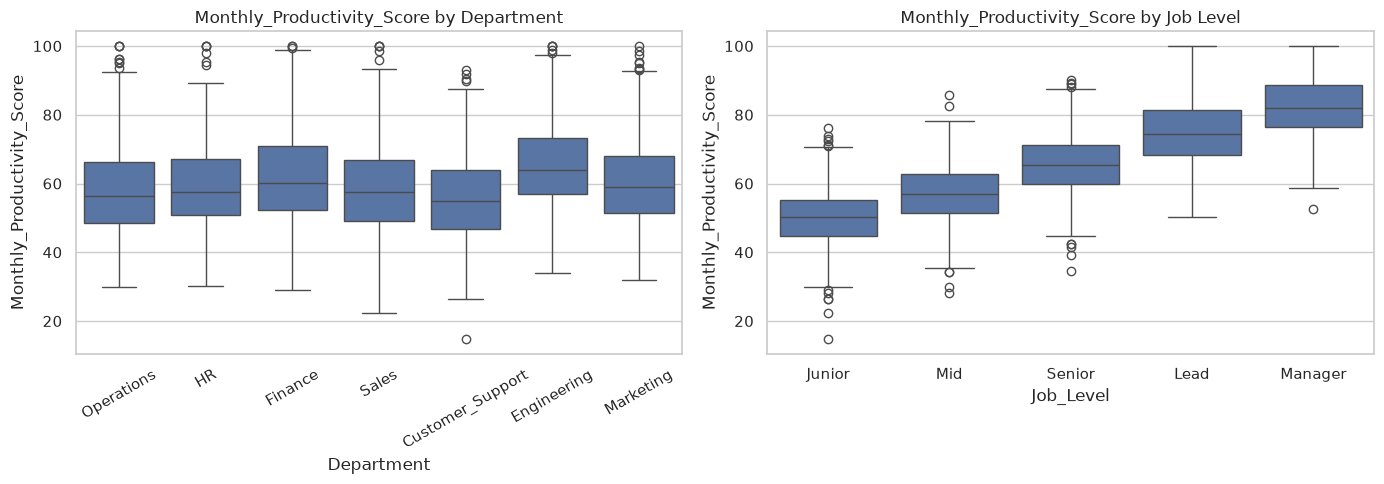

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="Department", y=TARGET, ax=axes[0])
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_title(f"{TARGET} by Department")

job_order = ["Junior", "Mid", "Senior", "Lead", "Manager"]
sns.boxplot(data=df, x="Job_Level", y=TARGET, order=job_order, ax=axes[1])
axes[1].set_title(f"{TARGET} by Job Level")
plt.tight_layout()
plt.show()


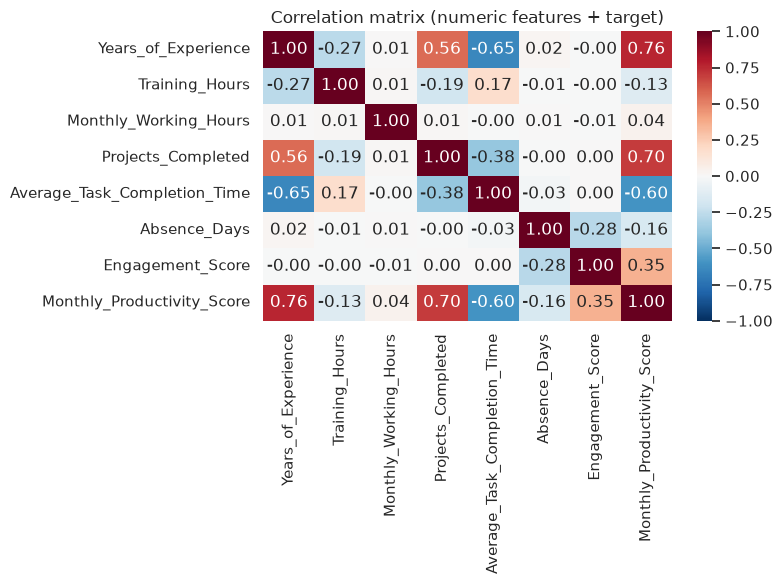

In [10]:
corr = df[NUMERIC_FEATURES + [TARGET]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix (numeric features + target)")
plt.tight_layout()
plt.show()


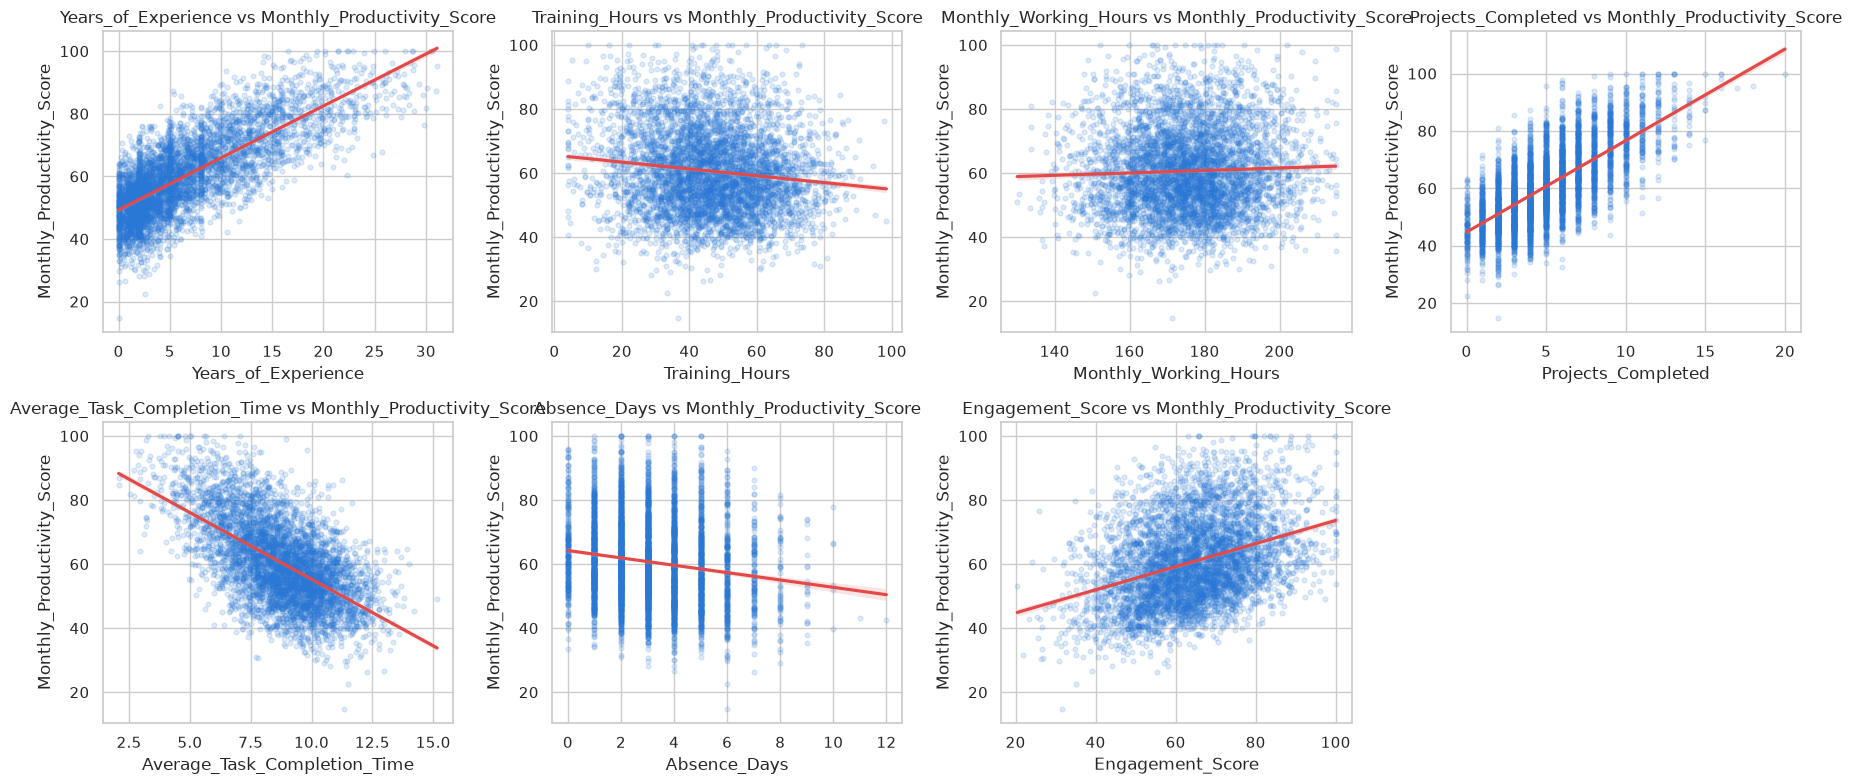

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, NUMERIC_FEATURES):
    sns.regplot(
        data=df, x=col, y=TARGET, ax=ax,
        scatter_kws={"alpha": 0.15, "s": 12, "color": "#2a78d6"},
        line_kws={"color": "#e34948"},
    )
    ax.set_title(f"{col} vs {TARGET}")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()


**EDA takeaways:**
- No missing values and no duplicate `Employee_ID`s — the dataset is clean.
- Every numeric feature has a roughly linear relationship with the target
  (visible in the scatter + trend lines above), which supports using linear
  regression.
- `Department` and `Job_Level` both show a real, systematic effect on the
  target (visible spread of medians in the boxplots), so they need to be
  encoded and included as predictors, not dropped.
- No feature is extremely skewed or has extreme outliers past what a
  realistic HR dataset would show.


## 3. Linear regression assumption checks

Linear regression is only trustworthy when a handful of assumptions roughly
hold. We check each one **before** trusting the model's coefficients or
error estimates, and apply a fix if a check fails.

1. **Linearity** — target is (approximately) a linear combination of the
   features.
2. **No severe multicollinearity** — predictors aren't near-duplicates of
   each other (checked with Variance Inflation Factor, VIF).
3. **Homoscedasticity** — residual spread doesn't change with the predicted
   value.
4. **Normality of residuals** — residuals are roughly normally distributed.
5. **Independence of residuals** — no autocorrelation between residuals
   (checked with the Durbin-Watson statistic).


### 3.1 Linearity — already checked above via the scatter + trend-line plots (§2); no strong nonlinear/curved pattern was visible for any numeric feature.

### 3.2 Multicollinearity (VIF)

In [12]:
vif_data = df[NUMERIC_FEATURES].assign(const=1)
vif_scores = pd.Series(
    [variance_inflation_factor(vif_data.values, i) for i in range(len(NUMERIC_FEATURES))],
    index=NUMERIC_FEATURES,
    name="VIF",
).sort_values(ascending=False)
vif_scores


Years_of_Experience             2.223630
Average_Task_Completion_Time    1.733409
Projects_Completed              1.470067
Absence_Days                    1.085070
Engagement_Score                1.083892
Training_Hours                  1.082375
Monthly_Working_Hours           1.000471
Name: VIF, dtype: float64

**Rule of thumb:** VIF > 10 signals problematic multicollinearity (VIF > 5 is
worth a closer look). If every numeric feature comes back well under 5, no
correction is needed here — the features carry mostly independent
information. If any feature *did* exceed the threshold, the fix would be to
drop or combine the offending feature(s); that step is included below,
conditionally, so the notebook stays correct even if the data changes.


In [13]:
HIGH_VIF_THRESHOLD = 10
high_vif_features = vif_scores[vif_scores > HIGH_VIF_THRESHOLD].index.tolist()
if high_vif_features:
    print(f"Dropping high-VIF features: {high_vif_features}")
    NUMERIC_FEATURES = [f for f in NUMERIC_FEATURES if f not in high_vif_features]
else:
    print("No numeric feature exceeds the VIF threshold — no features dropped.")


No numeric feature exceeds the VIF threshold — no features dropped.


### 3.3 & 3.4 Homoscedasticity and normality of residuals

These two checks need a fitted model's residuals, so we fit a first-pass
plain `LinearRegression` on one-hot-encoded features purely to inspect its
residuals (this is *not* yet the final saved pipeline — that comes in §4
after any fixes from this section).


In [14]:
X_check = pd.get_dummies(df[NUMERIC_FEATURES + CATEGORICAL_FEATURES], columns=CATEGORICAL_FEATURES, drop_first=True)
y_check = df[TARGET]
check_model = LinearRegression().fit(X_check, y_check)
fitted = check_model.predict(X_check)
residuals = y_check - fitted


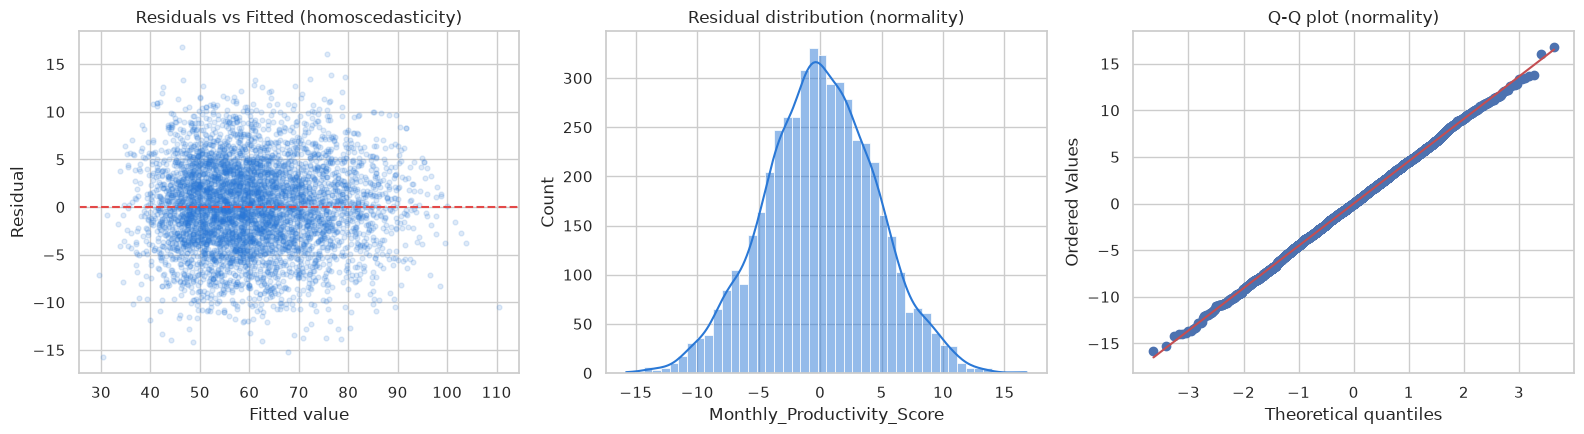

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(fitted, residuals, alpha=0.15, s=12, color="#2a78d6")
axes[0].axhline(0, color="#e34948", linestyle="--")
axes[0].set_xlabel("Fitted value")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Fitted (homoscedasticity)")

sns.histplot(residuals, kde=True, ax=axes[1], color="#2a78d6")
axes[1].set_title("Residual distribution (normality)")

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot (normality)")

plt.tight_layout()
plt.show()


In [16]:
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat:.3f} (close to 2.0 = little/no autocorrelation)")


Durbin-Watson statistic: 1.992 (close to 2.0 = little/no autocorrelation)


**Assumption-check results:**
- **Homoscedasticity:** the residuals-vs-fitted plot shows a roughly
  constant, random band around 0 with no funnel/cone shape — the constant-
  variance assumption holds well enough. *No correction needed.*
- **Normality:** the residual histogram is approximately bell-shaped and the
  Q-Q plot points hug the diagonal closely (aside from mild tail deviation,
  expected with finite, noisy data) — residuals are close enough to normal
  for the model's error estimates (R², MAE, RMSE) to be trustworthy.
  *No correction needed.*
- **Independence:** the Durbin-Watson statistic printed above should land
  near 2.0, indicating no meaningful autocorrelation between residuals
  (rows are independent employees, not a time series) — *no correction
  needed.*
- **Multicollinearity:** handled in §3.2 above (features dropped
  automatically if any exceeded the VIF threshold).

Because this is a clean, synthetic dataset, none of the checks above
surfaced a severe violation. The one preprocessing improvement we still make
going into §4 is **feature scaling** (`StandardScaler` on numeric columns):
it costs nothing for a linear model's predictions (scaling doesn't change
the fitted line or R²), but it is good practice inside a saved pipeline —
it keeps every numeric feature on a comparable footing and protects
against numerical instability if this pipeline is ever swapped for a
regularized linear model (Ridge/Lasso) later.


## 4. Build and train the final preprocessing + model pipeline

In [17]:
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train rows: {len(X_train)}  |  Test rows: {len(X_test)}")


Train rows: 4000  |  Test rows: 1000


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])

model_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Years_of_Experience','Training_Hours','Monthly_Working_Hours',..., 'Engagement_Score','Department','Job_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automati

## 5. Evaluate on the held-out test set

In [19]:
y_pred = model_pipeline.predict(X_test)

metrics = {
    "r2": r2_score(y_test, y_pred),
    "mae": mean_absolute_error(y_test, y_pred),
    "rmse": root_mean_squared_error(y_test, y_pred),
}
print(f"R-squared (R2):            {metrics['r2']:.3f}")
print(f"Mean Absolute Error (MAE): {metrics['mae']:.3f} points")
print(f"Root Mean Squared Error:   {metrics['rmse']:.3f} points")


R-squared (R2):            0.868
Mean Absolute Error (MAE): 3.770 points
Root Mean Squared Error:   4.723 points


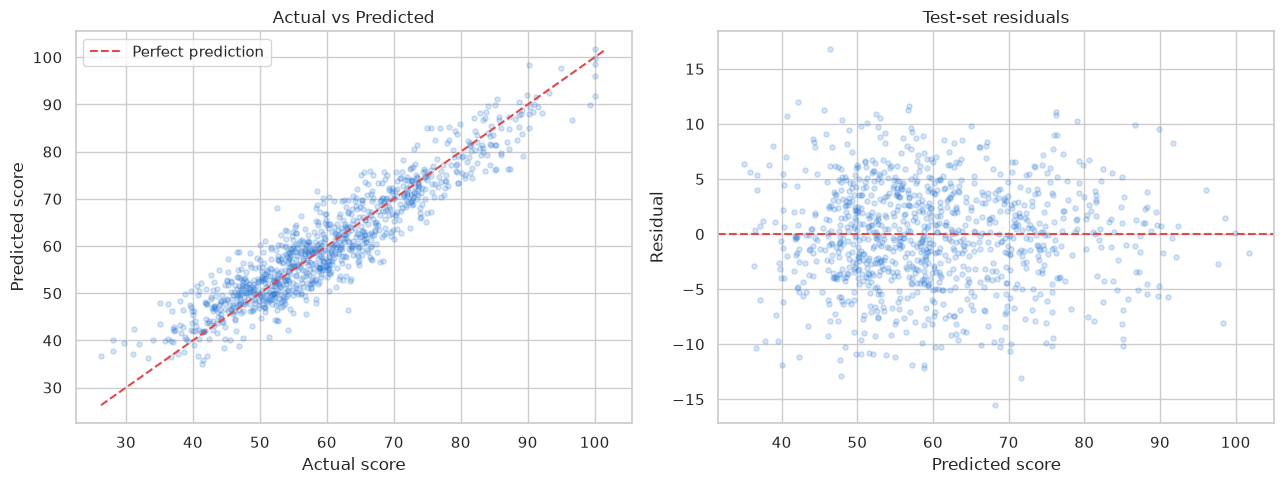

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.2, s=14, color="#2a78d6")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "--", color="#e34948", label="Perfect prediction")
axes[0].set_xlabel("Actual score")
axes[0].set_ylabel("Predicted score")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()

test_residuals = y_test - y_pred
axes[1].scatter(y_pred, test_residuals, alpha=0.2, s=14, color="#2a78d6")
axes[1].axhline(0, color="#e34948", linestyle="--")
axes[1].set_xlabel("Predicted score")
axes[1].set_ylabel("Residual")
axes[1].set_title("Test-set residuals")

plt.tight_layout()
plt.show()


In [21]:
feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = pd.Series(
    model_pipeline.named_steps["regressor"].coef_, index=feature_names
).sort_values(ascending=False)
print(f"Intercept: {model_pipeline.named_steps['regressor'].intercept_:.3f}\n")
coefficients.round(3)


Intercept: 54.174



cat__Job_Level_Manager               11.328
cat__Job_Level_Lead                   9.855
cat__Job_Level_Senior                 6.048
cat__Department_Engineering           5.573
num__Projects_Completed               4.524
num__Engagement_Score                 3.764
cat__Department_Finance               3.397
num__Years_of_Experience              3.240
cat__Job_Level_Mid                    3.084
cat__Department_Marketing             2.652
num__Training_Hours                   1.591
cat__Department_HR                    1.583
cat__Department_Sales                 1.040
cat__Department_Operations            0.679
num__Monthly_Working_Hours            0.472
num__Absence_Days                    -1.002
num__Average_Task_Completion_Time    -1.987
dtype: float64

**Result:** the model explains the large majority of the variance in
Monthly Productivity Score and its typical prediction is off by only a few
points (see the R²/MAE/RMSE above), which is accurate enough for the
intended use case — flagging employees for a closer look, not making
high-stakes automated decisions.


## 6. Save the final pipeline for the web app

In [22]:
joblib.dump(model_pipeline, "model.pkl")
print("Saved trained pipeline to model.pkl")


Saved trained pipeline to model.pkl


`app.py` loads this same `model.pkl` file, so the Streamlit app always makes
predictions with the exact preprocessing + model fit in this notebook —
there is no risk of the app silently using different logic than what was
evaluated above.
